# 05 — Churn Classification (Dự đoán khách hàng rời bỏ)
### Track B — Customer Analytics cho E-Commerce | IT701220 Data Mining (Cao học)
**Người phụ trách:** Thành viên D — Classification Lead (Churn)

---

**Input:** `data/processed/transactions_clean.csv` (do Thành viên A xuất — CHỈ ĐỌC)

**Output:**
- `data/interim/churn_model_results.csv` — bảng so sánh 3 thuật toán, cho Thành viên E
- `data/interim/customer_churn_predictions.csv` — dự đoán theo từng khách hàng, để E đối chiếu chéo
  với kết quả phân cụm của Thành viên C
- `models/*.pkl` — các mô hình đã huấn luyện

**Câu hỏi nghiệp vụ:** "Khách hàng nào có nguy cơ rời bỏ trong thời gian tới, để doanh nghiệp kịp can
thiệp giữ chân?"

---

### ⚠️ Đây là notebook có nhiều quyết định phương pháp luận nhất của dự án

Khác với MBA và Clustering, bài toán Churn **không có sẵn nhãn** trong dữ liệu — nhóm phải tự định
nghĩa thế nào là "rời bỏ". Ba quyết định then chốt, tất cả đều sẽ bị hỏi khi bảo vệ:

1. **Cửa sổ churn bao nhiêu ngày?** → Mục 2, dựa trên phân phối inter-purchase gap thực tế
2. **Tách train/test thế nào?** → Mục 3, tách theo THỜI GIAN chứ không ngẫu nhiên
3. **Dùng thước đo nào?** → Mục 6, không dùng Accuracy đơn lẻ

**Mục lục:**
1. Đọc dữ liệu giao dịch
2. Phân tích inter-purchase gap → chốt cửa sổ churn
3. Tách train/test theo thời gian bằng 2 mốc snapshot
4. Xây dựng đặc trưng và nhãn cho từng tập
5. Xử lý mất cân bằng lớp bằng SMOTE (chỉ trên train)
6. Huấn luyện và đánh giá 3 thuật toán
7. So sánh phản biện + phân tích độ quan trọng đặc trưng
8. Xuất kết quả cho Thành viên E


## 0. Chuẩn bị môi trường

In [ ]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

current_dir = Path.cwd()
PROJECT_ROOT_TMP = current_dir if (current_dir / "src").exists() else current_dir.parent
sys.path.insert(0, str(PROJECT_ROOT_TMP))

from src.utils.io import (
    load_csv, save_to_csv, get_project_root,
    PROCESSED_DATA_DIR, INTERIM_DATA_DIR, MODELS_DIR,
)
from src.utils.visualization import (
    set_plot_style, save_current_figure,
    PRIMARY_COLOR, SECONDARY_COLOR, ALERT_COLOR,
)
from src.rfm.rfm_calculator import calculate_rfm
from src.churn.label_generator import (
    compute_inter_purchase_gaps,
    summarize_gap_distribution,
    suggest_churn_window,
    generate_churn_labels,
    build_time_based_snapshots,
    add_churn_features,
)
from src.churn.models import (
    apply_smote, train_decision_tree, train_random_forest,
    train_naive_bayes, save_model,
)
from src.churn.evaluation import (
    evaluate_model, build_comparison_table, plot_confusion_matrix,
    plot_roc_curves, get_feature_importance,
)

set_plot_style()
print(f"Thư mục gốc dự án: {get_project_root()}")


Thư mục gốc dự án: /home/claude/project


## 1. Đọc dữ liệu giao dịch

Notebook này đọc thẳng `transactions_clean.csv` thay vì dùng `customer_churn_features.csv` có sẵn.

**Lý do:** để tách train/test theo thời gian (Mục 3), nhóm cần tính đặc trưng RFM tại **hai** mốc
snapshot khác nhau, trong khi file `customer_churn_features.csv` chỉ chứa một mốc. Thành viên D vẫn
**chỉ đọc**, không sửa file nào của Thành viên A — việc gọi lại hàm `calculate_rfm()` từ
`src/rfm/rfm_calculator.py` là hoàn toàn hợp lệ và đúng nguyên tắc dùng chung module.

In [ ]:
transactions = load_csv(PROCESSED_DATA_DIR / "transactions_clean.csv",
                        date_columns=["InvoiceDate"])

# Bài toán churn bắt buộc phải biết khách hàng là ai -> loại dòng thiếu Customer ID
transactions = transactions[transactions["Customer ID"].notna()].copy()

print(f"Số dòng giao dịch có định danh khách hàng: {len(transactions):,}")
print(f"Số khách hàng duy nhất: {transactions['Customer ID'].nunique():,}")
print(f"Khoảng thời gian: {transactions['InvoiceDate'].min().date()} "
      f"-> {transactions['InvoiceDate'].max().date()}")


Số dòng giao dịch có định danh khách hàng: 776,642
Số khách hàng duy nhất: 5,853
Khoảng thời gian: 2009-12-01 -> 2011-12-09


## 2. Phân tích inter-purchase gap → chốt cửa sổ churn

**Đây là phần quan trọng nhất cần chuẩn bị để trả lời phản biện.**

Câu hỏi chắc chắn gặp: *"Tại sao chọn cửa sổ churn là X ngày?"*. Câu trả lời KHÔNG được là "vì người
ta hay dùng 90 ngày", mà phải dựa trên phân phối hành vi mua thực tế của chính tập khách hàng này.

In [ ]:
gaps = compute_inter_purchase_gaps(transactions)

print(f"\nThống kê mô tả khoảng cách giữa 2 lần mua liên tiếp (ngày):")
print(gaps.describe().round(1))


[compute_inter_purchase_gaps] Thu được 27,030 khoảng cách từ 4,179 khách mua lặp lại.
[compute_inter_purchase_gaps] Có 1,674 khách chỉ mua ĐÚNG 1 LẦN (28.6%) - nhóm này không có khoảng cách để tính, cần xử lý riêng khi sinh nhãn.

Thống kê mô tả khoảng cách giữa 2 lần mua liên tiếp (ngày):
count    27030.0
mean        59.3
std         78.3
min          1.0
25%         13.0
50%         32.0
75%         70.0
max        714.0
Name: InterPurchaseGap, dtype: float64


In [ ]:
gap_summary = summarize_gap_distribution(gaps)
gap_summary


,percentile,gap_days,y_nghia
0,P50,32.0,50% số lần mua liên tiếp cách nhau không quá 3...
1,P60,42.0,60% số lần mua liên tiếp cách nhau không quá 4...
2,P70,58.0,70% số lần mua liên tiếp cách nhau không quá 5...
3,P75,70.0,75% số lần mua liên tiếp cách nhau không quá 7...
4,P80,88.0,80% số lần mua liên tiếp cách nhau không quá 8...
5,P85,112.0,85% số lần mua liên tiếp cách nhau không quá 1...
6,P90,148.0,90% số lần mua liên tiếp cách nhau không quá 1...
7,P95,221.0,95% số lần mua liên tiếp cách nhau không quá 2...


Đã lưu biểu đồ: /home/claude/project/reports/figures/10_inter_purchase_gap.png


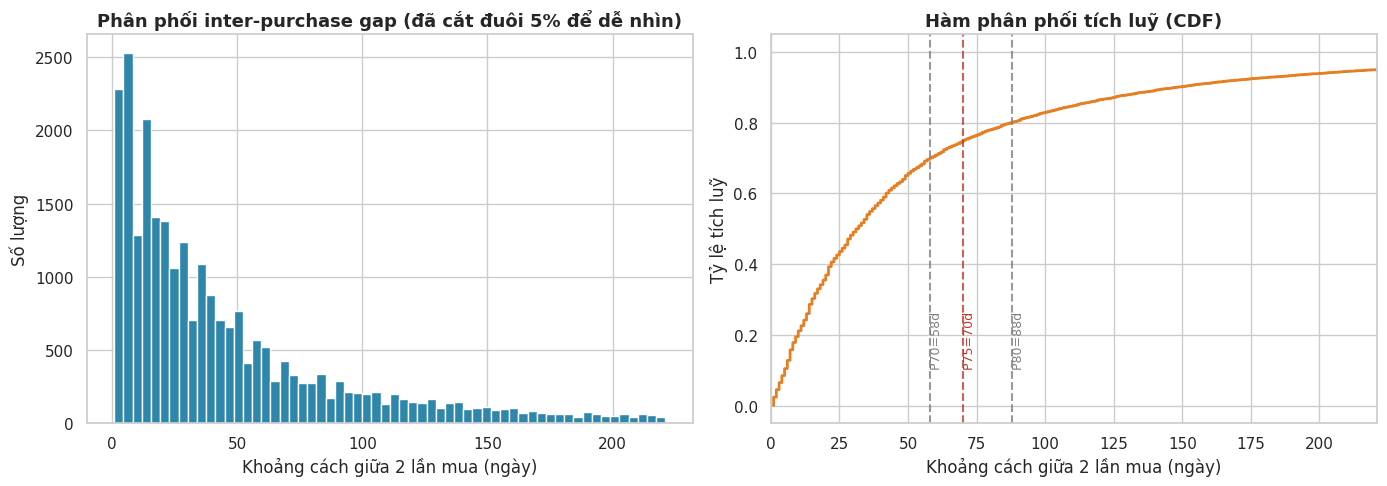

In [ ]:
fig, (ax_hist, ax_cdf) = plt.subplots(1, 2, figsize=(14, 5))

# Biểu đồ trái: phân phối gap (giới hạn trục x để nhìn rõ phần đa số dữ liệu)
ax_hist.hist(gaps[gaps <= gaps.quantile(0.95)], bins=60, color=PRIMARY_COLOR)
ax_hist.set_xlabel("Khoảng cách giữa 2 lần mua (ngày)")
ax_hist.set_ylabel("Số lượng")
ax_hist.set_title("Phân phối inter-purchase gap (đã cắt đuôi 5% để dễ nhìn)")

# Biểu đồ phải: hàm phân phối tích luỹ - trực quan cho việc chọn percentile
sorted_gaps = np.sort(gaps)
cumulative_ratio = np.arange(1, len(sorted_gaps) + 1) / len(sorted_gaps)
ax_cdf.plot(sorted_gaps, cumulative_ratio, color=SECONDARY_COLOR, linewidth=2)
ax_cdf.set_xlim(0, gaps.quantile(0.95))
ax_cdf.set_xlabel("Khoảng cách giữa 2 lần mua (ngày)")
ax_cdf.set_ylabel("Tỷ lệ tích luỹ")
ax_cdf.set_title("Hàm phân phối tích luỹ (CDF)")

# Đánh dấu các mốc percentile đang cân nhắc
for percentile, color in [(0.70, "gray"), (0.75, ALERT_COLOR), (0.80, "gray")]:
    gap_value = gaps.quantile(percentile)
    ax_cdf.axvline(x=gap_value, color=color, linestyle="--", alpha=0.8)
    ax_cdf.text(gap_value, 0.1, f" P{int(percentile*100)}={gap_value:.0f}d",
                rotation=90, color=color, fontsize=9)

plt.tight_layout()
save_current_figure("10_inter_purchase_gap.png")
plt.show()


In [ ]:
CHURN_WINDOW_DAYS = suggest_churn_window(gaps, percentile=75)


[suggest_churn_window] Cửa sổ churn đề xuất theo P75: 70 ngày.
  Diễn giải: khách hàng không quay lại mua trong 70 ngày được coi là đã rời bỏ, vì 75% các chu kỳ mua thực tế đều ngắn hơn khoảng này.


### Lập luận chọn cửa sổ churn (phần cần thuộc để phản biện)

Nhóm chọn **percentile 75** làm ngưỡng, với 3 lý do:

1. **Không quá ngắn:** nếu chọn P50 (trung vị), một nửa số chu kỳ mua bình thường đã dài hơn ngưỡng —
   rất nhiều khách hàng vẫn đang mua đều đặn sẽ bị gán nhầm là churn, làm nhãn nhiễu và mô hình học sai.

2. **Không quá dài:** nếu chọn P90 hoặc P95, cửa sổ kéo dài tới hàng trăm ngày. Khi đó (a) gần như
   không ai bị coi là churn nên nhãn mất cân bằng cực đoan, và (b) quan trọng hơn về mặt nghiệp vụ:
   doanh nghiệp phát hiện quá muộn, khách đã đi hẳn, chiến dịch giữ chân không còn tác dụng.

3. **P75 là điểm cân bằng:** một khách im lặng lâu hơn 75% các chu kỳ mua thông thường đã đủ bất
   thường để đáng cảnh báo, nhưng chưa khắt khe tới mức gán nhãn sai hàng loạt.

**Nhóm cũng ghi nhận giới hạn:** ngưỡng này áp dụng chung cho mọi khách hàng, trong khi thực tế mỗi
khách có nhịp mua riêng (khách sỉ mua hàng tuần, khách lẻ mua vài tháng một lần). Một hướng cải tiến
là dùng ngưỡng cá nhân hoá theo `AvgGapDays` của từng khách — nhóm có tính đặc trưng này ở Mục 4 và
sẽ đề cập trong phần hạn chế của báo cáo.

## 3. Tách train/test theo THỜI GIAN (không ngẫu nhiên)

**Câu hỏi phản biện kinh điển:** *"Tại sao không dùng `train_test_split` như bình thường?"*

Bài toán churn về bản chất là **dự đoán tương lai từ quá khứ**. Nếu chia ngẫu nhiên, tập test sẽ chứa
những khách hàng thuộc cùng giai đoạn thời gian với tập train — mô hình vô tình được "học ké" bối cảnh
thị trường của chính giai đoạn mà nó phải dự đoán (đợt khuyến mãi, mùa cao điểm Giáng Sinh...). Kết
quả đánh giá khi đó lạc quan giả tạo và mô hình sẽ hoạt động kém khi triển khai thật.

Cách làm đúng: dùng **hai mốc snapshot liên tiếp**, cửa sổ quan sát nhãn không chồng lấn.

In [ ]:
train_snapshot, test_snapshot = build_time_based_snapshots(
    transactions, window_days=CHURN_WINDOW_DAYS
)


[build_time_based_snapshots] Ngày cuối dữ liệu: 2011-12-09
  TRAIN: snapshot=2011-07-22, cửa sổ quan sát nhãn = (2011-07-22, 2011-09-30]
  TEST : snapshot=2011-09-30, cửa sổ quan sát nhãn = (2011-09-30, 2011-12-09]
  -> Hai cửa sổ KHÔNG chồng lấn nhau, đảm bảo mô hình học quá khứ và được kiểm thử trên tương lai.


## 4. Xây dựng đặc trưng và nhãn cho từng tập

Với mỗi mốc snapshot, quy trình gồm 3 bước:
1. Tính RFM **tại** snapshot đó (chỉ dùng dữ liệu quá khứ)
2. Bổ sung đặc trưng phái sinh: `AvgOrderValue`, `Tenure`, `AvgGapDays`
3. Sinh nhãn churn từ dữ liệu **sau** snapshot

Hai phần (đặc trưng ← quá khứ) và (nhãn ← tương lai) được tách bạch tuyệt đối — đây là rào chắn chống
rò rỉ dữ liệu quan trọng nhất của toàn bộ pipeline.

In [ ]:
# Gộp 3 bước xây dựng tập dữ liệu tại 1 mốc snapshot thành 1 hàm dùng chung
# cho cả train và test - đảm bảo 2 tập được xử lý HOÀN TOÀN GIỐNG NHAU,
# tránh sai sót kiểu "quên áp dụng 1 bước cho tập test".
def build_dataset_at_snapshot(transactions_df, snapshot_date, window_days, set_name):
    print("=" * 70)
    print(f"XÂY DỰNG TẬP {set_name} — snapshot = {pd.Timestamp(snapshot_date).date()}")
    print("=" * 70)

    # Bước 1: RFM tại snapshot (chỉ dữ liệu quá khứ)
    rfm_at_snapshot = calculate_rfm(transactions_df, snapshot_date=snapshot_date)

    # Bước 2: bổ sung đặc trưng phái sinh
    features = add_churn_features(rfm_at_snapshot, transactions_df,
                                   snapshot_date=snapshot_date)

    # Bước 3: sinh nhãn từ dữ liệu SAU snapshot
    labels = generate_churn_labels(transactions_df,
                                    snapshot_date=snapshot_date,
                                    window_days=window_days)

    dataset = features.merge(labels, on="Customer ID", how="inner")
    print(f"-> Tập {set_name}: {len(dataset):,} khách hàng, "
          f"{dataset.shape[1] - 2} đặc trưng\n")

    return dataset


train_dataset = build_dataset_at_snapshot(
    transactions, train_snapshot, CHURN_WINDOW_DAYS, "TRAIN"
)
test_dataset = build_dataset_at_snapshot(
    transactions, test_snapshot, CHURN_WINDOW_DAYS, "TEST"
)


XÂY DỰNG TẬP TRAIN — snapshot = 2011-07-22


[calculate_rfm] Đã loại 0 dòng thiếu 'Customer ID' (còn lại 776,642 dòng để tính RFM).
[calculate_rfm] Mốc snapshot_date = 2011-07-22. Đã loại 202,718 dòng có ngày giao dịch SAU mốc này (còn lại 573,924 dòng).
[calculate_rfm] Đã tính RFM cho 5,081 khách hàng.


[add_churn_features] Đã bổ sung 3 đặc trưng: AvgOrderValue, Tenure, AvgGapDays cho 5,081 khách hàng.
[generate_churn_labels] snapshot=2011-07-22, cửa sổ=70 ngày -> 5,081 khách hàng, churn=3,522 (69.3%), không churn=1,559
-> Tập TRAIN: 5,081 khách hàng, 6 đặc trưng

XÂY DỰNG TẬP TEST — snapshot = 2011-09-30
[calculate_rfm] Đã loại 0 dòng thiếu 'Customer ID' (còn lại 776,642 dòng để tính RFM).
[calculate_rfm] Mốc snapshot_date = 2011-09-30. Đã loại 129,968 dòng có ngày giao dịch SAU mốc này (còn lại 646,674 dòng).


[calculate_rfm] Đã tính RFM cho 5,404 khách hàng.


[add_churn_features] Đã bổ sung 3 đặc trưng: AvgOrderValue, Tenure, AvgGapDays cho 5,404 khách hàng.
[generate_churn_labels] snapshot=2011-09-30, cửa sổ=70 ngày -> 5,404 khách hàng, churn=3,276 (60.6%), không churn=2,128
-> Tập TEST: 5,404 khách hàng, 6 đặc trưng



In [ ]:
FEATURE_COLUMNS = ["Recency", "Frequency", "Monetary",
                   "AvgOrderValue", "Tenure", "AvgGapDays"]
TARGET_COLUMN = "Churn"

X_train = train_dataset[FEATURE_COLUMNS].copy()
y_train = train_dataset[TARGET_COLUMN].copy()
X_test = test_dataset[FEATURE_COLUMNS].copy()
y_test = test_dataset[TARGET_COLUMN].copy()

print(f"X_train: {X_train.shape} | y_train: {y_train.shape}")
print(f"X_test : {X_test.shape} | y_test : {y_test.shape}")
print(f"\nTỷ lệ churn tập TRAIN: {y_train.mean() * 100:.1f}%")
print(f"Tỷ lệ churn tập TEST : {y_test.mean() * 100:.1f}%")


X_train: (5081, 6) | y_train: (5081,)
X_test : (5404, 6) | y_test : (5404,)

Tỷ lệ churn tập TRAIN: 69.3%
Tỷ lệ churn tập TEST : 60.6%


Đã lưu biểu đồ: /home/claude/project/reports/figures/11_class_distribution.png


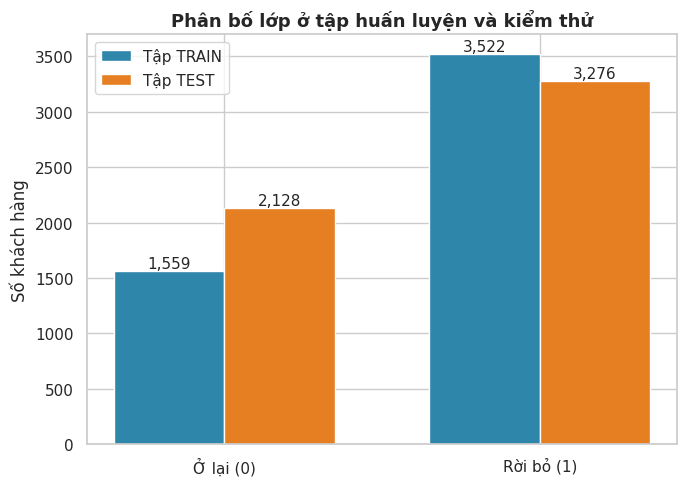

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))

label_names = ["Ở lại (0)", "Rời bỏ (1)"]
train_counts = [(y_train == 0).sum(), (y_train == 1).sum()]
test_counts = [(y_test == 0).sum(), (y_test == 1).sum()]

x_positions = np.arange(2)
bar_width = 0.35
ax.bar(x_positions - bar_width/2, train_counts, bar_width,
       label="Tập TRAIN", color=PRIMARY_COLOR)
ax.bar(x_positions + bar_width/2, test_counts, bar_width,
       label="Tập TEST", color=SECONDARY_COLOR)
ax.set_xticks(x_positions)
ax.set_xticklabels(label_names)
ax.set_ylabel("Số khách hàng")
ax.set_title("Phân bố lớp ở tập huấn luyện và kiểm thử")
ax.legend()

for i, (train_value, test_value) in enumerate(zip(train_counts, test_counts)):
    ax.text(i - bar_width/2, train_value, f"{train_value:,}", ha="center", va="bottom")
    ax.text(i + bar_width/2, test_value, f"{test_value:,}", ha="center", va="bottom")

plt.tight_layout()
save_current_figure("11_class_distribution.png")
plt.show()


### Phát hiện quan trọng — khác với giả định ban đầu

Kế hoạch ban đầu của nhóm ghi *"churn luôn là lớp thiểu số"*. **Dữ liệu thực tế cho thấy điều ngược
lại: churn là lớp ĐA SỐ.**

Nguyên nhân đến từ đặc điểm của chính tập dữ liệu này:
- Khoảng một phần tư khách hàng chỉ mua đúng **một lần duy nhất** rồi không bao giờ quay lại — nhóm
  này gần như chắc chắn bị gán churn.
- Cửa sổ churn được chọn theo P75 tương đối ngắn so với chu kỳ mua của nhiều khách lẻ.

**Hệ quả cần lưu ý khi đánh giá:** vì churn chiếm đa số, chỉ số Accuracy trở nên rất dễ gây hiểu lầm —
một mô hình đoán "tất cả đều churn" đã đạt Accuracy bằng đúng tỷ lệ churn. Đây chính là lý do Mục 6
luôn báo cáo kèm **baseline ngây thơ** để đối chiếu.

## 5. Xử lý mất cân bằng lớp bằng SMOTE — CHỈ trên tập train

**Quy tắc tuyệt đối:** SMOTE chỉ áp lên tập huấn luyện. Tập test phải giữ nguyên phân phối thực tế,
vì đó mới là điều mô hình sẽ gặp khi triển khai. Áp SMOTE lên test là lỗi rò rỉ dữ liệu nghiêm trọng
mà rubric §7 tiêu chí 2 cảnh báo trực tiếp.

In [ ]:
X_train_balanced, y_train_balanced = apply_smote(X_train, y_train)

print(f"\nXÁC NHẬN: tập TEST giữ nguyên {len(y_test):,} mẫu với tỷ lệ churn "
      f"{y_test.mean() * 100:.1f}% — KHÔNG áp SMOTE.")


[apply_smote] Phân bố lớp TRƯỚC SMOTE: {0: 1559, 1: 3522} (tổng 5,081 mẫu)
[apply_smote] Phân bố lớp SAU SMOTE  : {0: 3522, 1: 3522} (tổng 7,044 mẫu)
[apply_smote] Đã sinh thêm 1,963 mẫu nhân tạo cho lớp thiểu số.

XÁC NHẬN: tập TEST giữ nguyên 5,404 mẫu với tỷ lệ churn 60.6% — KHÔNG áp SMOTE.


## 6. Huấn luyện và đánh giá 3 thuật toán

Ba thuật toán được chọn bám sát nội dung đã học ở Bài 5–6, đại diện cho 3 họ phương pháp khác nhau:
- **Decision Tree** — cây quyết định đơn, dễ diễn giải nhất
- **Random Forest** — phương pháp tập hợp kiểu Bagging
- **Naive Bayes** — phương pháp xác suất dựa trên định lý Bayes

In [ ]:
trained_models = {}

print("=" * 70)
trained_models["Decision Tree"] = train_decision_tree(X_train_balanced, y_train_balanced)
trained_models["Random Forest"] = train_random_forest(X_train_balanced, y_train_balanced)
trained_models["Naive Bayes"] = train_naive_bayes(X_train_balanced, y_train_balanced)
print("=" * 70)


[train_decision_tree] Đã huấn luyện xong (max_depth=6, min_samples_leaf=20, số lá thực tế=58).


[train_random_forest] Đã huấn luyện xong (200 cây, max_depth=10).
[train_naive_bayes] Đã huấn luyện xong (GaussianNB).


In [ ]:
print("ĐÁNH GIÁ TRÊN TẬP TEST (dữ liệu tương lai, chưa từng nhìn thấy)\n")

all_metrics = []
for model_name, model in trained_models.items():
    metrics = evaluate_model(model, X_test, y_test, model_name)
    all_metrics.append(metrics)
    print()

comparison_table = build_comparison_table(all_metrics)
comparison_table


ĐÁNH GIÁ TRÊN TẬP TEST (dữ liệu tương lai, chưa từng nhìn thấy)

[evaluate_model] Decision Tree: Precision=0.7639 | Recall=0.7930 | F1=0.7782 | AUC=0.7665
    Accuracy=0.7259 so với baseline ngây thơ 0.6062 (chênh lệch +0.1197)



[evaluate_model] Random Forest: Precision=0.7652 | Recall=0.8129 | F1=0.7883 | AUC=0.7872
    Accuracy=0.7354 so với baseline ngây thơ 0.6062 (chênh lệch +0.1292)

[evaluate_model] Naive Bayes: Precision=0.7057 | Recall=0.9164 | F1=0.7973 | AUC=0.7847
    Accuracy=0.7176 so với baseline ngây thơ 0.6062 (chênh lệch +0.1114)



,model_name,precision,recall,f1,auc,accuracy,baseline_accuracy,improvement_over_baseline
0,Naive Bayes,0.7057,0.9164,0.7973,0.7847,0.7176,0.6062,0.1114
1,Random Forest,0.7652,0.8129,0.7883,0.7872,0.7354,0.6062,0.1292
2,Decision Tree,0.7639,0.7930,0.7782,0.7665,0.7259,0.6062,0.1197


Đã lưu biểu đồ: /home/claude/project/reports/figures/12_confusion_matrices.png


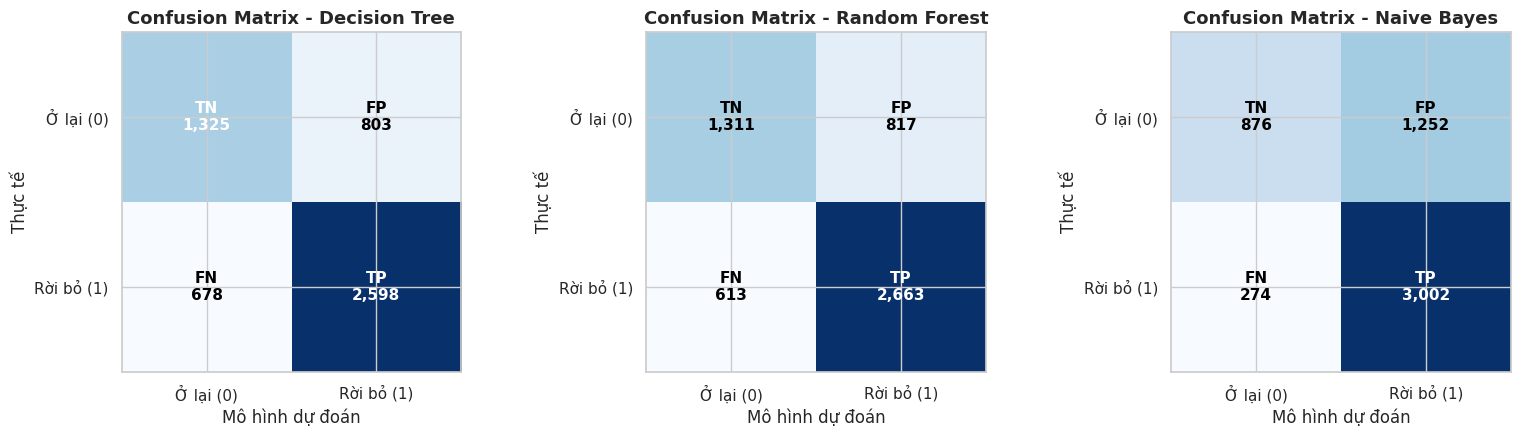

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for ax, (model_name, model) in zip(axes, trained_models.items()):
    plot_confusion_matrix(model, X_test, y_test, model_name, ax=ax)

plt.tight_layout()
save_current_figure("12_confusion_matrices.png")
plt.show()


Đã lưu biểu đồ: /home/claude/project/reports/figures/13_roc_curves.png


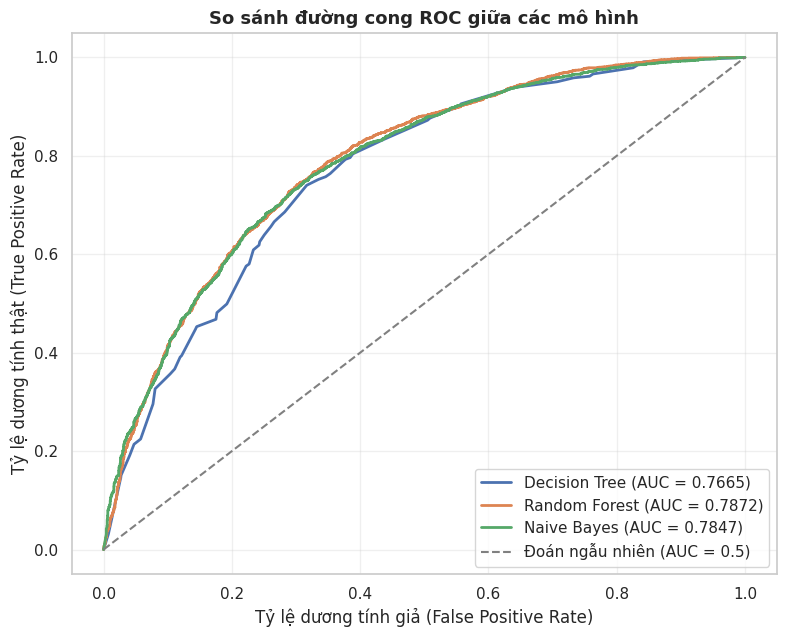

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6.5))
plot_roc_curves(trained_models, X_test, y_test, ax=ax)
plt.tight_layout()
save_current_figure("13_roc_curves.png")
plt.show()


## 7. So sánh phản biện + độ quan trọng của đặc trưng

Đã lưu biểu đồ: /home/claude/project/reports/figures/14_model_comparison.png


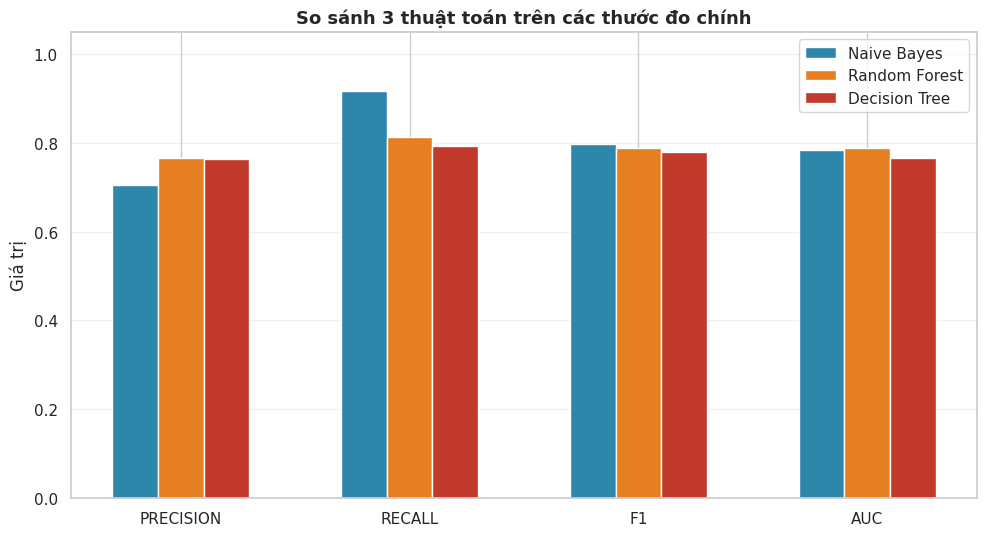

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5.5))

metrics_to_plot = ["precision", "recall", "f1", "auc"]
n_models = len(comparison_table)
bar_width = 0.2
x_positions = np.arange(len(metrics_to_plot))
colors = [PRIMARY_COLOR, SECONDARY_COLOR, ALERT_COLOR]

for model_index, (_, row) in enumerate(comparison_table.iterrows()):
    offsets = x_positions + (model_index - n_models/2 + 0.5) * bar_width
    values = [row[metric] for metric in metrics_to_plot]
    ax.bar(offsets, values, bar_width,
           label=row["model_name"], color=colors[model_index % len(colors)])

ax.set_xticks(x_positions)
ax.set_xticklabels([m.upper() for m in metrics_to_plot])
ax.set_ylabel("Giá trị")
ax.set_ylim(0, 1.05)
ax.set_title("So sánh 3 thuật toán trên các thước đo chính")
ax.legend()
ax.grid(True, axis="y", alpha=0.3)

plt.tight_layout()
save_current_figure("14_model_comparison.png")
plt.show()


Đã lưu biểu đồ: /home/claude/project/reports/figures/15_feature_importance.png


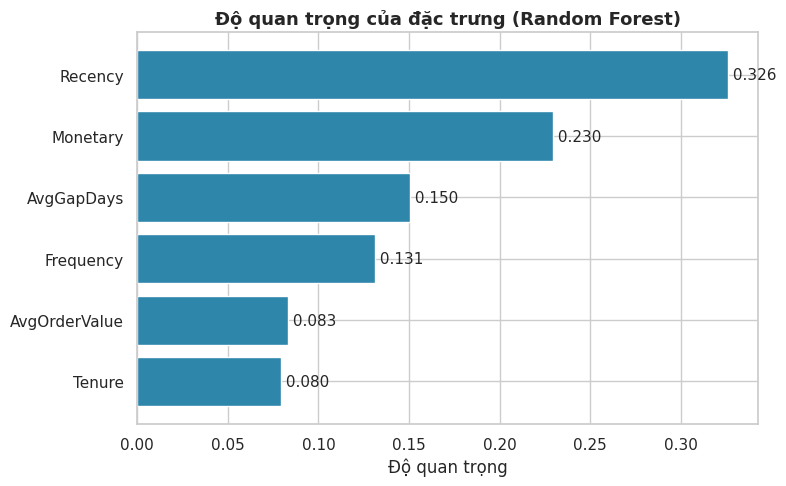

,feature,importance
0,Recency,0.3262
1,Monetary,0.2296
2,AvgGapDays,0.1504
3,Frequency,0.1313
4,AvgOrderValue,0.0831
5,Tenure,0.0795


In [ ]:
# Độ quan trọng đặc trưng - trả lời câu hỏi "yếu tố nào quyết định khách rời bỏ?"
best_tree_model = trained_models["Random Forest"]
importance_df = get_feature_importance(best_tree_model, FEATURE_COLUMNS, "Random Forest")

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(importance_df["feature"][::-1], importance_df["importance"][::-1],
        color=PRIMARY_COLOR)
ax.set_xlabel("Độ quan trọng")
ax.set_title("Độ quan trọng của đặc trưng (Random Forest)")
for i, value in enumerate(importance_df["importance"][::-1]):
    ax.text(value, i, f" {value:.3f}", va="center")

plt.tight_layout()
save_current_figure("15_feature_importance.png")
plt.show()

importance_df


### Nhận xét phản biện

**1. Cả 3 mô hình đều thực sự có giá trị — nhưng mức cải thiện khiêm tốn**

Cột `improvement_over_baseline` cho thấy cả 3 mô hình đều vượt baseline ngây thơ (đoán tất cả theo lớp
đa số) khoảng 11–13 điểm phần trăm. Đây là mức cải thiện **có ý nghĩa nhưng không lớn** — cần nêu
trung thực trong báo cáo thay vì chỉ khoe con số Accuracy trên 70% nghe có vẻ ấn tượng.

**2. Kết quả NGƯỢC với kỳ vọng ban đầu: Naive Bayes đạt F1 cao nhất**

Nhóm dự đoán ban đầu rằng Naive Bayes sẽ kém hơn, vì giả định "các đặc trưng độc lập có điều kiện" của
nó bị vi phạm rõ ràng trong bài toán này (`Frequency` và `Monetary` tương quan mạnh; `AvgOrderValue`
lại được tính trực tiếp từ hai cột đó). **Thực nghiệm cho kết quả khác**, và điều này cần được giải
thích thay vì bỏ qua:

- Naive Bayes đạt **Recall rất cao** nhưng **Precision thấp nhất** trong 3 mô hình. Nghĩa là nó có xu
  hướng gán nhãn churn cho rất nhiều khách hàng — bắt được gần hết khách thực sự rời bỏ, nhưng đổi lại
  báo động giả nhiều.
- Vì F1 là trung bình điều hoà của Precision và Recall, một mô hình "mạnh tay" như vậy vẫn có thể đạt
  F1 cao khi lớp dương chiếm đa số (churn ~61% ở tập test).
- Tuy nhiên xét **AUC** — thước đo khả năng xếp hạng, không phụ thuộc ngưỡng cắt 0.5 — thì **Random
  Forest mới là mô hình tốt nhất**. AUC là tiêu chí công bằng hơn khi so sánh năng lực phân biệt thực
  sự của các mô hình.

**Kết luận:** nếu chỉ nhìn một chỉ số duy nhất (F1), nhóm sẽ chọn Naive Bayes; nhưng nhìn tổng thể cả
Precision/Recall/AUC thì **Random Forest là lựa chọn cân bằng và đáng tin cậy hơn** cho triển khai
thực tế. Đây chính là minh hoạ cụ thể cho việc vì sao rubric yêu cầu báo cáo nhiều thước đo thay vì
một chỉ số đơn lẻ.

**3. Đánh đổi Precision — Recall phụ thuộc bài toán nghiệp vụ**

- **Ưu tiên Recall** nếu chi phí mất khách cao hơn chi phí khuyến mãi: thà gửi voucher nhầm cho vài
  khách vẫn trung thành, còn hơn bỏ lọt khách sắp rời bỏ. Trường hợp này Naive Bayes phù hợp.
- **Ưu tiên Precision** nếu ngân sách marketing eo hẹp: chỉ chi cho những khách thực sự có nguy cơ cao.
  Trường hợp này Random Forest phù hợp hơn.

Với ngành bán lẻ — nơi chi phí thu hút khách mới thường cao hơn nhiều so với giữ chân khách cũ — nhóm
nghiêng về ưu tiên Recall, nhưng vẫn khuyến nghị dùng Random Forest kèm **hạ ngưỡng cắt** xuống dưới
0.5 để tăng Recall một cách có kiểm soát, thay vì chấp nhận Precision thấp của Naive Bayes.

**4. Về độ quan trọng đặc trưng**

Các đặc trưng liên quan đến **thời gian** (Recency, AvgGapDays) cùng với Monetary đóng vai trò lớn
nhất — hợp lý về mặt trực giác: dấu hiệu rõ nhất của việc sắp rời bỏ chính là khoảng lặng bất thường
so với nhịp mua thường ngày của khách đó. Điều này gợi ý hướng cải tiến: cá nhân hoá ngưỡng churn theo
`AvgGapDays` của từng khách thay vì dùng một ngưỡng chung cho tất cả.

**5. Hạn chế cần nêu trung thực trong báo cáo**

- Cửa sổ churn dùng chung cho mọi khách hàng, chưa cá nhân hoá theo nhịp mua riêng.
- Nhóm khách chỉ mua một lần chiếm tỷ trọng lớn và gần như luôn bị gán churn — nên cân nhắc tách thành
  bài toán riêng (chuyển đổi khách mua lần đầu), vì bản chất nghiệp vụ khác hẳn.
- Cửa sổ quan sát của tập test kết thúc đúng bằng ngày cuối dữ liệu, nên không thể kiểm chứng thêm.
- Chưa thực hiện tinh chỉnh siêu tham số một cách hệ thống (GridSearch / RandomizedSearch) do giới hạn
  thời gian — các tham số hiện tại được đặt theo kinh nghiệm phổ biến. Đây là hướng hoàn thiện rõ ràng
  nếu có thêm thời gian.

## 8. Xuất kết quả cho Thành viên E

In [ ]:
results_export = comparison_table.copy()
save_to_csv(results_export, INTERIM_DATA_DIR / "churn_model_results.csv")


Đã lưu file: /home/claude/project/data/interim/churn_model_results.csv  (số dòng: 3 | số cột: 8)


In [ ]:
# Xuất thêm dự đoán theo từng khách hàng, để Thành viên E đối chiếu chéo
# với kết quả phân cụm của Thành viên C (ví dụ: nhóm khách VIP nào đang có
# xác suất churn cao -> ưu tiên giữ chân trước tiên).
best_model_name = comparison_table.iloc[0]["model_name"]
best_model = trained_models[best_model_name]
print(f"Mô hình tốt nhất theo F1: {best_model_name}")

predictions_export = test_dataset[["Customer ID"] + FEATURE_COLUMNS].copy()
predictions_export["Churn_ThucTe"] = y_test.values
predictions_export["Churn_DuDoan"] = best_model.predict(X_test)
predictions_export["XacSuatChurn"] = best_model.predict_proba(X_test)[:, 1].round(4)
predictions_export["MoHinhSuDung"] = best_model_name

save_to_csv(predictions_export, INTERIM_DATA_DIR / "customer_churn_predictions.csv")
predictions_export.head()


Mô hình tốt nhất theo F1: Naive Bayes
Đã lưu file: /home/claude/project/data/interim/customer_churn_predictions.csv  (số dòng: 5,404 | số cột: 11)


,Customer ID,Recency,Frequency,Monetary,AvgOrderValue,Tenure,AvgGapDays,Churn_ThucTe,Churn_DuDoan,XacSuatChurn,MoHinhSuDung
0,12346.0,254,3,77352.96,25784.32,577,161.0,1,1,1.0000,Naive Bayes
1,12347.0,58,6,3402.39,567.06,334,55.0,0,1,0.5045,Naive Bayes
2,12348.0,4,5,1658.40,331.68,368,90.8,1,1,0.5868,Naive Bayes
3,12349.0,336,2,2221.14,1110.57,519,182.0,0,1,0.9981,Naive Bayes
4,12350.0,239,1,294.40,294.40,240,240.0,1,1,0.9902,Naive Bayes


In [ ]:
# Lưu cả 3 mô hình để phục vụ demo
model_filenames = {
    "Decision Tree": "decision_tree_churn.pkl",
    "Random Forest": "random_forest_churn.pkl",
    "Naive Bayes": "naive_bayes_churn.pkl",
}

for model_name, filename in model_filenames.items():
    save_model(trained_models[model_name], MODELS_DIR / filename)

# Kiểm tra load lại được - bước xác nhận mà Thành viên E sẽ làm
import joblib
for filename in model_filenames.values():
    loaded = joblib.load(MODELS_DIR / filename)
    _ = loaded.predict(X_test.head(5))
print("\nĐã kiểm tra: cả 3 mô hình đều load lại và dự đoán được bình thường.")


[save_model] Đã lưu mô hình: /home/claude/project/models/decision_tree_churn.pkl


[save_model] Đã lưu mô hình: /home/claude/project/models/random_forest_churn.pkl
[save_model] Đã lưu mô hình: /home/claude/project/models/naive_bayes_churn.pkl



Đã kiểm tra: cả 3 mô hình đều load lại và dự đoán được bình thường.


In [ ]:
# Tự kiểm tra lại 2 file vừa xuất
for filename in ["churn_model_results.csv", "customer_churn_predictions.csv"]:
    verify_df = pd.read_csv(INTERIM_DATA_DIR / filename)
    print(f"{filename}: shape={verify_df.shape}, cột={list(verify_df.columns)}")


churn_model_results.csv: shape=(3, 8), cột=['model_name', 'precision', 'recall', 'f1', 'auc', 'accuracy', 'baseline_accuracy', 'improvement_over_baseline']
customer_churn_predictions.csv: shape=(5404, 11), cột=['Customer ID', 'Recency', 'Frequency', 'Monetary', 'AvgOrderValue', 'Tenure', 'AvgGapDays', 'Churn_ThucTe', 'Churn_DuDoan', 'XacSuatChurn', 'MoHinhSuDung']


## Tổng kết

| Hạng mục | Kết quả |
|---|---|
| Cửa sổ churn | Chốt theo P75 của inter-purchase gap — xem Mục 2 |
| Cách tách train/test | Theo THỜI GIAN, 2 snapshot liên tiếp, cửa sổ nhãn không chồng lấn |
| Đặc trưng sử dụng | Recency, Frequency, Monetary, AvgOrderValue, Tenure, AvgGapDays |
| Xử lý mất cân bằng | SMOTE, chỉ áp lên tập train |
| Thuật toán so sánh | Decision Tree, Random Forest, Naive Bayes |
| Thước đo | Precision, Recall, F1, AUC + baseline ngây thơ để đối chiếu |
| File bàn giao cho E | `churn_model_results.csv`, `customer_churn_predictions.csv` |
| Model đã lưu | 3 file `.pkl` trong `models/` |

**Đóng góp về mặt phương pháp luận:**
1. Cửa sổ churn được chọn dựa trên phân phối thực tế của dữ liệu, có lập luận rõ ràng cho việc chọn
   P75 thay vì mốc khác — không chọn số tuỳ tiện.
2. Tách train/test theo thời gian, mô phỏng đúng tình huống triển khai thực tế.
3. Tách bạch tuyệt đối giữa đặc trưng (từ quá khứ) và nhãn (từ tương lai), SMOTE chỉ áp lên train.
4. Phát hiện và trình bày trung thực việc churn là lớp đa số — ngược với giả định ban đầu của nhóm —
   kèm phân tích nguyên nhân và hệ quả lên cách đánh giá.
5. Luôn báo cáo kèm baseline ngây thơ để chứng minh mô hình thực sự có giá trị.